In [ ]:
import os


os.environ['USER'] = 'shaans321'
os.environ['REPO'] = 'shaans-ml'
os.environ['TOKEN'] = '****'
# do everything in colab's "root" directory
%cd /content
!git clone https://${TOKEN}@github.com/${USER}/${REPO}.git

# make sure your repo shows up
%ls

/content
Cloning into 'dl-hw'...
remote: Enumerating objects: 51858, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 51858 (delta 8), reused 8 (delta 5), pack-reused 51842 (from 5)
Receiving objects: 100% (51858/51858), 561.36 MiB | 13.24 MiB/s, done.
Resolving deltas: 100% (2595/2595), done.
Updating files: 100% (70258/70258), done.
dl-hw/  sample_data/


In [2]:
%cd /content/{os.environ['REPO']}
%ls

# go to a specific homework
#%mkdir -p aih-hrp/
%cd aih-hrp/
%ls


/content/dl-hw
aih-hrp/  Homework/
/content/dl-hw/aih-hrp
Classifier_Muradataset_20250413_1epoch.th  mura_resnet18_for_ELBOW_DS.pt
Classifier.th                              mura_resnet18_fulldataset25epo.pt
metrics_train.json                         mura_resnet18.pt
model.py                                   train.py
mura_dataset                               utils.py
mura_dataset.py


In [3]:
HOMEWORK_DIR='/content/dl-hw/aih-hrp'

In [ ]:
# refreshes python imports automatically when you edit the source file
# %load_ext autoreload
# %autoreload 2

Data Setup

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("panagiotiskyrmpatsos/mura-v11")

print("Path to dataset files:", path)
root_path = path

Using Colab cache for faster access to the 'mura-v11' dataset.
Path to dataset files: /kaggle/input/mura-v11


In [ ]:
print(path)

/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4


In [ ]:
# list files from path

import os

# Assuming 'path' variable is defined from the previous code cell
# and contains the path to the downloaded dataset
if 'path' in locals():
  for filename in os.listdir(path):
    print(f"{path=}")
    print(f"{filename}")

else:
  print("Error: 'path' variable not found. Please run the kagglehub dataset download code first.")


path='/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4'
phase_1_resnet_mon_jun_26_23-28-30_2023.pt
path='/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4'
MURA_fn_train.csv
path='/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4'
MURA_fn_dev.csv
path='/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4'
MURA-v1.1


In [ ]:
for filename in os.listdir(path):
  print(f"{path=}")
  print(f"{filename}")

path='/kaggle/input/mura-v11'
MURA_fn_dev.csv
path='/kaggle/input/mura-v11'
MURA_fn_train.csv
path='/kaggle/input/mura-v11'
MURA-v1.1
path='/kaggle/input/mura-v11'
phase_1_resnet_mon_jun_26_23-28-30_2023.pt


In [5]:
import pandas as pd
df_train_labeled_studies = pd.read_csv(os.path.join(path, "MURA-v1.1/MURA-v1.1/train_labeled_studies.csv"))
df_train_labeled_studies.head(2)

,MURA-v1.1/train/XR_SHOULDER/patient00001/study1_positive/,1
0,MURA-v1.1/train/XR_SHOULDER/patient00002/study...,1
1,MURA-v1.1/train/XR_SHOULDER/patient00003/study...,1


In [6]:
import pandas as pd

df = pd.read_csv(os.path.join(path, "MURA_fn_dev.csv"))
print(f"{df.head()=}")  # Print first few rows to verify
print(f"{df.shape=}")
print(f"{df.info()=}")
print(f"{df.describe()=}")


df.head()=   Unnamed: 0.1  Unnamed: 0  \
0          1941        1941   
1          2333        2333   
2          4447        4447   
3            58          58   
4          1258        1258   

                                                path  Split      Bone  \
0  MURA-v1.1\train\XR_ELBOW\patient05290\study1_p...  train  XR_ELBOW   
1  MURA-v1.1\train\XR_ELBOW\patient05413\study1_p...  train  XR_ELBOW   
2  MURA-v1.1\train\XR_ELBOW\patient06185\study1_n...  train  XR_ELBOW   
3  MURA-v1.1\train\XR_ELBOW\patient00370\study1_n...  train  XR_ELBOW   
4  MURA-v1.1\train\XR_ELBOW\patient05067\study1_p...  train  XR_ELBOW   

        Patient       FolderName   Study     Label  
0  patient05290  study1_positive  study1  positive  
1  patient05413  study1_positive  study1  positive  
2  patient06185  study1_negative  study1  negative  
3  patient00370  study1_negative  study1  negative  
4  patient05067  study1_positive  study1  positive  
df.shape=(3680, 9)
<class 'pandas.core.frame.D

In [ ]:
df.describe()

,Unnamed: 0.1,Unnamed: 0
count,3680.000000,3680.000000
mean,18497.421467,18497.421467
std,10716.242913,10716.242913
min,5.000000,5.000000
25%,9280.250000,9280.250000
50%,18459.000000,18459.000000
75%,27659.500000,27659.500000
max,36806.000000,36806.000000


In [7]:
import pandas as pd
df_MURA_fn_dev = pd.read_csv(os.path.join(path, "MURA_fn_dev.csv"))
df_MURA_fn_dev.head(2)

,Unnamed: 0.1,Unnamed: 0,path,Split,Bone,Patient,FolderName,Study,Label
0,1941,1941,MURA-v1.1\train\XR_ELBOW\patient05290\study1_p...,train,XR_ELBOW,patient05290,study1_positive,study1,positive
1,2333,2333,MURA-v1.1\train\XR_ELBOW\patient05413\study1_p...,train,XR_ELBOW,patient05413,study1_positive,study1,positive


In [ ]:
df_MURA_fn_dev['Label'].value_counts()

,count
Label,
negative,2225
positive,1455


In [ ]:
# Total number of images
total_images = len(df_MURA_fn_dev)
print(f"Total number of images in df_MURA_fn_dev: {total_images}")


Total number of images in df_MURA_fn_dev: 3680


In [ ]:
df_MURA_fn_dev['Label'].value_counts()

,count
Label,
negative,2225
positive,1455


In [ ]:
#MURA stats

import pandas as pd

# Number of unique patients
unique_patients = df_MURA_fn_dev['Patient'].nunique()
print(f"Number of unique patients: {unique_patients}")

# Image stats by bone and label
image_stats = df_MURA_fn_dev.groupby(['Bone', 'Label']).size().unstack(fill_value=0)
print("\nImage stats by bone and label:")
image_stats

Number of unique patients: 3190

Image stats by bone and label:


Label,negative,positive
Bone,,
XR_ELBOW,281,212
XR_FINGER,318,193
XR_FOREARM,105,77
XR_HAND,406,148
XR_HUMERUS,73,54
XR_SHOULDER,436,402
XR_WRIST,606,369


In [8]:
df_MURA_fn_train = pd.read_csv(os.path.join(path, "MURA_fn_train.csv"))

In [ ]:
# Total number of images
total_images = len(df_MURA_fn_train)
print(f"Total number of images in df_MURA_fn_train: {total_images}")

Total number of images in df_MURA_fn_train: 33128


In [ ]:
df_MURA_fn_train.head(2)

,Unnamed: 0.1,Unnamed: 0,path,Split,Bone,Patient,FolderName,Study,Label
0,0,0,MURA-v1.1\train\XR_ELBOW\patient00011\study1_n...,train,XR_ELBOW,patient00011,study1_negative,study1,negative
1,1,1,MURA-v1.1\train\XR_ELBOW\patient00011\study1_n...,train,XR_ELBOW,patient00011,study1_negative,study1,negative


In [ ]:
# Count matching 'path' column values
matching_paths = df_MURA_fn_train['path'].isin(df_MURA_fn_dev['path']).sum()
print(f"Number of matching paths: {matching_paths}")

Number of matching paths: 0


In [ ]:
#list of all subdirectories and files from path,"MURA-v1.1"

import os
print(f"{path=}")
def list_files_and_subdirectories(path):
  """Lists all subdirectories and files from the given path."""
  if not os.path.exists(path):
      print(f"Error: Path '{path}' does not exist.")
      return
  i=0
  for root, dirs, files in os.walk(path):
      level = root.replace(path, '').count(os.sep)
      indent = ' ' * 4 * (level)
      #print('{}{}/'.format(indent, os.path.basename(root)))
      subindent = ' ' * 4 * (level + 1)
      full_path = os.path.join(path, root)
      #print(full_path)
      i+=1
      if i==10:
        break
      for f in files:
          #print('{}{}'.format(subindent, f))
          print(full_path+"/"+f)
          break

# Assuming 'path' variable is defined from the previous code cell
# and contains the path to the downloaded dataset
if 'path' in locals():
  list_files_and_subdirectories(path)
else:
  print("Error: 'path' variable not found. Please run the kagglehub dataset download code first.")


path='/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4'
/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA_fn_dev.csv
/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA-v1.1/MURA-v1.1/train_image_paths.csv
/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA-v1.1/MURA-v1.1/train/XR_FOREARM/patient09114/study1_positive/image3.png
/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA-v1.1/MURA-v1.1/train/XR_FOREARM/patient09515/study1_negative/image2.png


/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA-v1.1/MURA-v1.1/valid/XR_HAND/patient11583/study1_negative/image4.png


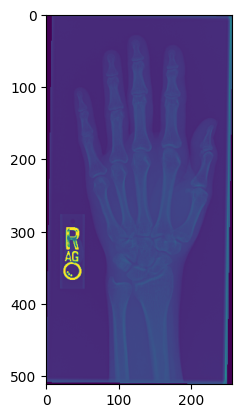

torch.Size([512, 258])
torch.Size([512, 258])
torch.float32
torch.Size([512, 258]) torch.Size([512, 258]) torch.float32


/tmp/ipykernel_3905/1032678373.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img_tensor = torch.tensor(img1)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import torch
# Assuming 'path' variable is defined from the previous code cell
# and contains the path to the downloaded dataset
#file1=os.path.join(path,"MURA-v1.1","/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA-v1.1/MURA-v1.1/train/XR_SHOULDER/patient02008/study1_negative/image1.png")
#file1=os.path.join(path,"MURA-v1.1","train/XR_SHOULDER/patient02008/study1_negative/image1.png")
#print(f"{file1=}")
#/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA-v1.1\train\XR_ELBOW\patient05290\study1_positive\image1.png
#/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA-v1.1/MURA-v1.1/train/XR_SHOULDER/patient02008/study1_negative/image1.png
#/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/mura-v11/MURA-v1.1/train/XR_ELBOW/patient00011/study1_negative/image1.png
#file1='/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/valid/XR_WRIST/patient11268/study1_positive/image1.png'
file1='/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA-v1.1/MURA-v1.1/valid/XR_HAND/patient11583/study1_negative/image4.png'
print(file1)
# Read and display the image
plt.imshow(mpimg.imread(file1))
plt.show()

img1=torch.tensor(mpimg.imread(file1))
print(img1.shape)
print(img1.size())
print(img1.dtype)
img_tensor = torch.tensor(img1)
print(img_tensor.shape, img_tensor.size(), img_tensor.dtype)

Text(0.5, 1.0, '/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA-v1.1/MURA-v1.1/train/XR_ELBOW/patient00011/study1_negative/image1.png')
Text(0.5, 1.0, '/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA-v1.1/MURA-v1.1/train/XR_ELBOW/patient00011/study1_negative/image2.png')
Text(0.5, 1.0, '/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA-v1.1/MURA-v1.1/train/XR_ELBOW/patient00011/study1_negative/image3.png')
Text(0.5, 1.0, '/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA-v1.1/MURA-v1.1/train/XR_ELBOW/patient00016/study1_positive/image1.png')
Text(0.5, 1.0, '/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA-v1.1/MURA-v1.1/train/XR_ELBOW/patient00016/study1_positive/image2.png')
Text(0.5, 1.0, '/root/.cache/kagglehub/datasets/panagiotiskyrmpatsos/mura-v11/versions/4/MURA-v1.1/MURA-v1.1/train/XR_ELBOW/patient00026/study1_negative/image1.png')
Text

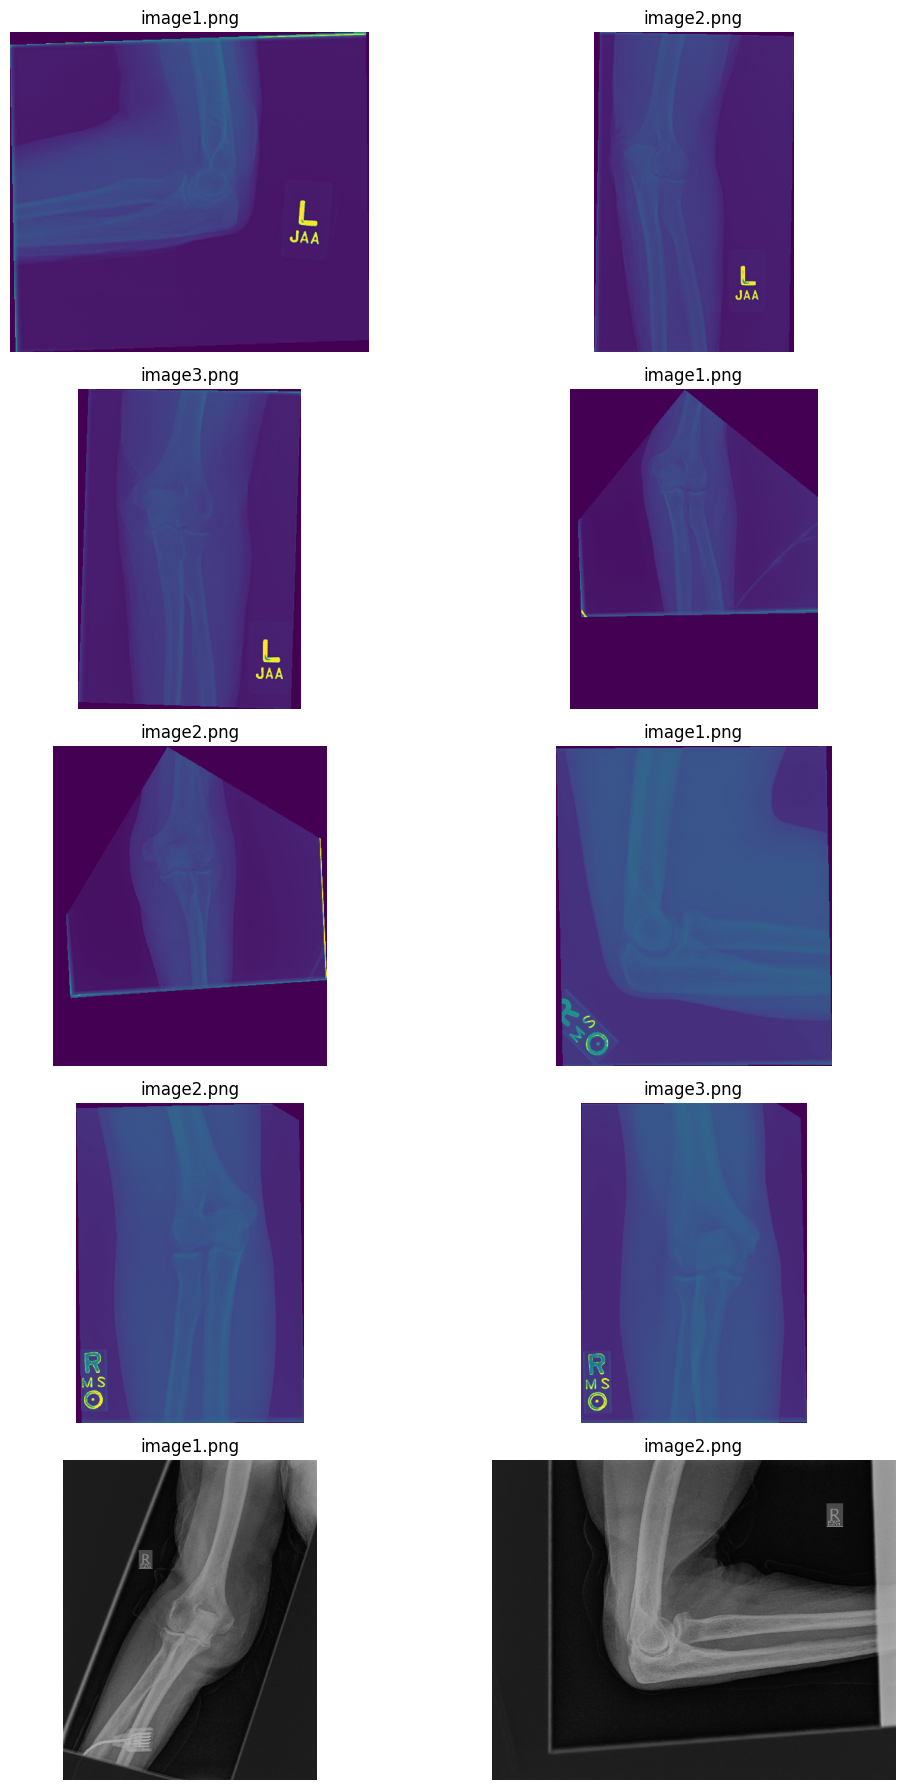

In [ ]:

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os


def plot_images(image_paths, rows=5, cols=2):
    fig, axes = plt.subplots(rows, cols, figsize=(12, 18))  # Adjust figsize as needed
    axes = axes.ravel()  # Flatten the axes array for easy iteration
    for i, image_path in enumerate(image_paths):
      print(axes[i].set_title(image_path))
    for i, image_path in enumerate(image_paths):
        if i >= rows * cols:
            break  # Stop if we've filled all the subplots
        try:
            img = mpimg.imread(image_path)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(image_path))  # Set title to filename
            #axes[i].set_title(image_path)  # Set title to filename
            axes[i].axis('off') # Hide axes
        except FileNotFoundError:
            print(f"Error: File not found - {image_path}")
        except Exception as e:
            print(f"Error displaying image {image_path}: {e}")

    plt.tight_layout()  # Adjust layout to prevent overlapping titles
    plt.show()


# Example usage: Plot the first 10 images from df_MURA_fn_dev
if 'df_MURA_fn_train' in locals() and 'path' in locals():
    image_paths = [os.path.join(path,'MURA-v1.1', p.replace("\\", "/")) for p in df_MURA_fn_train['path'][0:10]]
    plot_images(image_paths)

else:
    print("Error: 'df_MURA_fn_dev' or 'path' variable not found. Please run the necessary code cells first.")


In [9]:
!pip install kagglehub
!pip install torch torchvision
import kagglehub
import os
import csv
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader # Import Dataset from torch.utils.data
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [10]:
#COmplete dataset this may run out of memory

!pip install kagglehub
!pip install torch torchvision
import kagglehub
import os
import csv
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader # Import Dataset from torch.utils.data
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# %%
import os
#/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/
#MURA-v1.1\train\XR_ELBOW\
path = kagglehub.dataset_download("panagiotiskyrmpatsos/mura-v11")
#path = kagglehub.dataset_download("panagiotiskyrmpatsos/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_ELBOW")
class MuraDataSet(Dataset):
    def __init__(self, dataset_path: str):
        """
        Pairs of images and labels (int) for classification
        """
        #to_tensor = transforms.ToTensor()
        ## Below transform for Resnet
        #self.transform = transforms.Compose([
        #    transforms.Resize((512, 512)),  # Resize to a common size
        #    transforms.ToTensor(),
        #    # 3 channels
        #    transforms.Lambda(lambda x: x.repeat(3, 1, 1) if x.shape[0] == 1 else x)
        #])

        ## Below transform for SWIN Tranformer
        self.transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

        LABEL_NAMES=['negative','positive']
        self.data = []

        #dataset_path='/content/MURA_fn_train.csv' #Temporary for testing with sample file
        #with open(Path(dataset_path), newline="") as f:
        with open(Path(dataset_path), newline="") as f:
            print(f"{dataset_path=}")
            i=0
            for _,_,filepath,_,_,_,_,_,label in csv.reader(f):
                #image_path = os.path.join(path,'MURA-v1.1/MURA-v1.1/train/XR_ELBOW', filepath.replace("\\", "/"))
                image_path = os.path.join(path,'MURA-v1.1', filepath.replace("\\", "/")) #training just ELBOW due to large memory and huge compute
                #i+=1
                #if i==100:
                #  break
                if label in LABEL_NAMES:
                    image = Image.open(Path(image_path))
                    # Apply the transform to resize and convert to tensor
                    image = self.transform(image)
                    label_id = LABEL_NAMES.index(label)

                    self.data.append((image, label_id))
                    #print(f"{image_path=}")
                    #print(f"{label_id=}")
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


def load_data(dataset_path: str, num_workers: int = 0, batch_size: int = 128, shuffle: bool = False) -> DataLoader:
    dataset = MuraDataSet(dataset_path)

    return DataLoader(dataset, num_workers=num_workers, batch_size=batch_size, shuffle=shuffle, drop_last=True,pin_memory=True)

Using Colab cache for faster access to the 'mura-v11' dataset.


In [ ]:
### DONOT RUN ###
#Restricting to specific bone ex. Bone =XR_ELBOW
!pip install kagglehub
!pip install torch torchvision
import kagglehub
import os
import csv
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader # Import Dataset from torch.utils.data
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# %%
from torch.utils.data import Dataset, DataLoader # Import Dataset from torch.utils.data
import os
#/kaggle/input/mura-v11/MURA-v1.1/MURA-v1.1/
#MURA-v1.1\train\XR_ELBOW\
path = kagglehub.dataset_download("panagiotiskyrmpatsos/mura-v11")
#path = kagglehub.dataset_download("panagiotiskyrmpatsos/mura-v11/MURA-v1.1/MURA-v1.1/train/XR_ELBOW")
#Remove Comments to train by specific bone
class MuraDataSet_Elbow(Dataset):
    def __init__(self, dataset_path: str):
        """
        Pairs of images and labels (int) for classification
        You won't need to modify this, but all PyTorch datasets must implement these methods
        """
        #to_tensor = transforms.ToTensor()
        self.transform = transforms.Compose([
            transforms.Resize((512, 512)),  # Resize to a common size
            transforms.ToTensor(),
            # Add this line to ensure 3 channels
            transforms.Lambda(lambda x: x.repeat(3, 1, 1) if x.shape[0] == 1 else x)
        ])
        LABEL_NAMES=['negative','positive']
        self.data = []

        #dataset_path='/content/MURA_fn_train.csv' #Temporary for testing with sample file
        #with open(Path(dataset_path), newline="") as f:
        with open(Path(dataset_path), newline="") as f:
            print(f"{dataset_path=}")
            i=0
            for _,_,filepath,_,Bone,_,_,_,label in csv.reader(f):
              if Bone in ('XR_ELBOW'):
                #image_path = os.path.join(path,'MURA-v1.1/MURA-v1.1/train/XR_ELBOW', filepath.replace("\\", "/"))
                image_path = os.path.join(path,'MURA-v1.1', filepath.replace("\\", "/")) #training just ELBOW due to large memory and huge compute
                #i+=1
                #if i==100:
                #  break
                if label in LABEL_NAMES:
                    image = Image.open(Path(image_path))
                    # Apply the transform to resize and convert to tensor
                    image = self.transform(image)
                    label_id = LABEL_NAMES.index(label)

                    self.data.append((image, label_id))
                    #print(f"{image_path=}")
                    #print(f"{label_id=}")
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


def load_data(dataset_path: str, num_workers: int = 0, batch_size: int = 128, shuffle: bool = False) -> DataLoader:
    dataset = MuraDataSet(dataset_path)

    return DataLoader(dataset, num_workers=num_workers, batch_size=batch_size, shuffle=shuffle, drop_last=True,pin_memory=True)

Using Colab cache for faster access to the 'mura-v11' dataset.


#Using ResNet50

In [11]:
import os
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import pandas as pd


In [12]:
import csv
from pathlib import Path
import os
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

# Mean and std for MURA normalization, adapted for Swin Transformer
INPUT_MEAN = [0.485, 0.456, 0.406]
INPUT_STD = [0.229, 0.224, 0.225]

# Transforms for Swin Transformer
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(INPUT_MEAN, INPUT_STD),
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(INPUT_MEAN, INPUT_STD),
])

# Dataset class
class MURADataset(Dataset):
    def __init__(self, csv_file, root_dir_path, transform=None):
        self.transform = transform
        LABEL_NAMES=['negative','positive']
        self.samples = [] # Store (image_path, label_id) pairs
        self.root_dir_path = root_dir_path

        with open(csv_file, newline="") as f:
            # Skip header row
            next(f, None)
            for row in csv.reader(f):
                # Assuming the CSV format has path, Bone, and label in known columns
                # Adjust indices if your CSV structure is different
                # For 'MURA_fn_dev.csv'/'MURA_fn_train.csv', relevant columns seem to be at index 2 (filepath) and 8 (label)
                filepath = row[2]
                label_str = row[8] # Get the label string first
                #Bone = row[4] # If you need to filter by bone, you can uncomment this
                image_path = os.path.join(self.root_dir_path,'MURA-v1.1', filepath.replace("\\", "/"))

                if label_str in LABEL_NAMES:
                    label_id = LABEL_NAMES.index(label_str)
                    self.samples.append((image_path, label_id))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, label_id = self.samples[idx]

        image = Image.open(Path(image_path)).convert('RGB')
        if self.transform:
            image = self.transform(image)

        return image, label_id


In [15]:
#Resnet50
import os
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import pandas as pd
from tqdm import tqdm # Import tqdm for progress bar

# Model with pretrained ResNet18
class MURAClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, 2)

    def forward(self, x):
        return self.backbone(x)

# Accuracy metric
def compute_accuracy(preds, labels):
    return (preds == labels).sum().item() / len(labels)

# Training function
def train_model(train_csv, val_csv, epochs=25, batch_size=16, lr=0.001):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_loader = DataLoader(
        MURADataset(train_csv, root_dir_path=path, transform=train_tfms),
        batch_size=batch_size, shuffle=True, num_workers=2)

    val_loader = DataLoader(
        MURADataset(val_csv, root_dir_path=path, transform=val_tfms),
        batch_size=batch_size, shuffle=False, num_workers=2)

    model = MURAClassifier().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss()

    # Lists to store metrics
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        current_train_loss = 0
        train_correct = 0
        train_total = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = loss_fn(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            current_train_loss += loss.item()
            preds = logits.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        scheduler.step()
        avg_train_loss = current_train_loss / len(train_loader)
        train_acc = train_correct / train_total
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_acc)

        # Validation
        model.eval()
        current_val_loss = 0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} Validation"):
                images, labels = images.to(device), labels.to(device)
                logits = model(images)
                loss = loss_fn(logits, labels)
                current_val_loss += loss.item()
                preds = logits.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        avg_val_loss = current_val_loss / len(val_loader)
        val_acc = val_correct / val_total
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")

    torch.save(model.state_dict(), "mura_resnet50_fulldataset25epo.pt")
    print("Model saved as `mura_resnet50_fulldataset25epo.pt`")

    return train_losses, val_losses, train_accuracies, val_accuracies

In [ ]:
# to continue training for additional epoch. load the previous trained model
from google.colab import files

# This will open a file picker dialog for you to upload the .pth file
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  # If you need to access the content, it's in uploaded[fn]
  # For example, to save it:
  # with open(fn, 'wb') as f:
  #    f.write(uploaded[fn])

print("File upload complete.")

Saving mura_resnet18_fulldataset25epo.pt to mura_resnet18_fulldataset25epo (1).pt
User uploaded file "mura_resnet18_fulldataset25epo (1).pt" with length 44794123 bytes
File upload complete.


In [ ]:
model = MURAClassifier()
model.load_state_dict(torch.load('mura_resnet50_fulldataset25epo.pt'))
model.eval() # Set the model to evaluation mode
print("Model 'mura_resnet50_fulldataset25epo.pt' loaded successfully.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 122MB/s]


Model 'mura_resnet18_fulldataset25epo.pt' loaded successfully.


In [25]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_csv = os.path.join( path,'MURA_fn_train.csv')
val_csv = os.path.join( path,'MURA_fn_dev.csv')
train_losses, val_losses, train_accuracies, val_accuracies=train_model(train_csv, val_csv, epochs=25, batch_size=16, lr=0.001)

Epoch 1 Validation: 100%|██████████| 230/230 [00:25<00:00,  9.15it/s]


Epoch 01/25 | Train Loss: 0.6680 | Train Acc: 0.5973 | Val Loss: 0.7349 | Val Acc: 0.5288


Epoch 2 Validation: 100%|██████████| 230/230 [00:24<00:00,  9.21it/s]


Epoch 02/25 | Train Loss: 0.6614 | Train Acc: 0.6032 | Val Loss: 0.6595 | Val Acc: 0.6125


Epoch 3 Validation: 100%|██████████| 230/230 [00:26<00:00,  8.84it/s]


...

Epoch 23/25 | Train Loss: 0.4864 | Train Acc: 0.7705 | Val Loss: 0.4952 | Val Acc: 0.7685


Epoch 24 Validation: 100%|██████████| 230/230 [00:25<00:00,  9.20it/s]


Epoch 24/25 | Train Loss: 0.4842 | Train Acc: 0.7716 | Val Loss: 0.4926 | Val Acc: 0.7682


Epoch 25 Validation: 100%|██████████| 230/230 [00:25<00:00,  9.09it/s]


Epoch 25/25 | Train Loss: 0.4832 | Train Acc: 0.7706 | Val Loss: 0.4908 | Val Acc: 0.7679
Model saved as `mura_resnet50_fulldataset25epo.pt`


Re-running training to collect metrics...


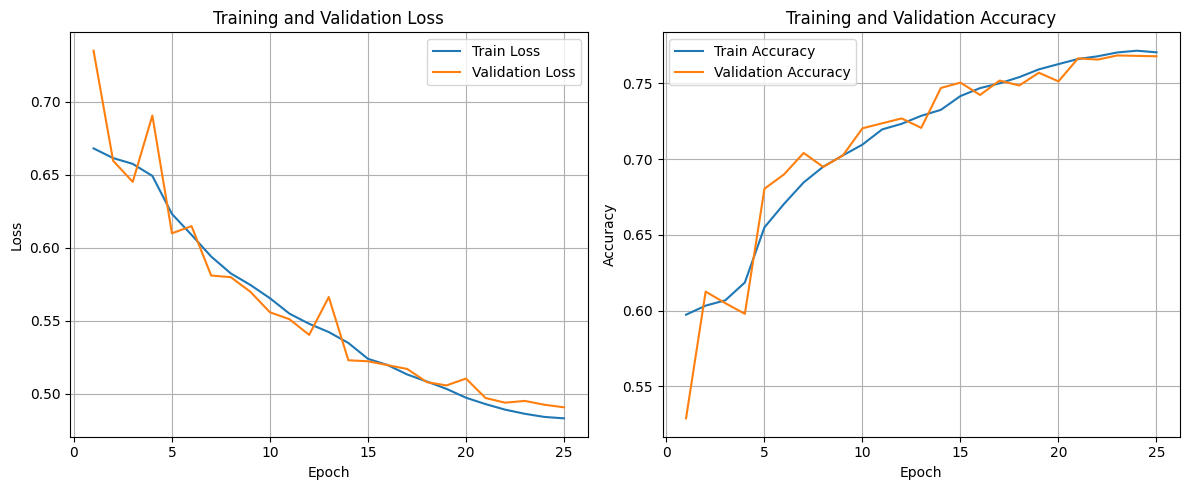

In [26]:
import matplotlib.pyplot as plt
import os

# Re-run the training to get the metrics
print("Re-running training to collect metrics...")
#train_losses, val_losses, train_accuracies, val_accuracies = train_model(train_csv, val_csv, epochs=25, batch_size=16, lr=0.001)

# Plotting the metrics
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

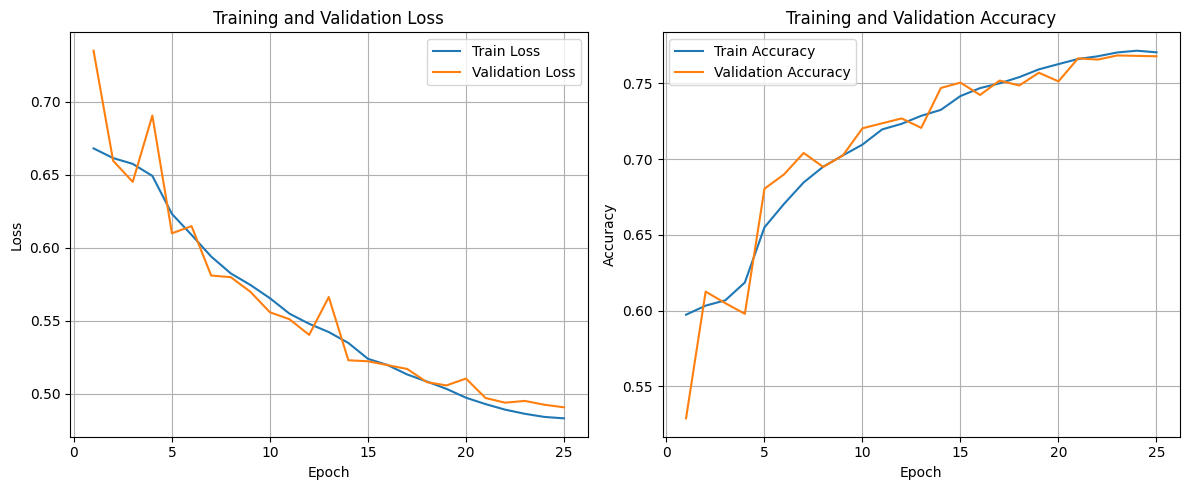

In [27]:
import matplotlib.pyplot as plt

# Plotting the metrics
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:

%ls
!git status

# Be careful not to "git add *" since there are datasets and logs
!git add aih-hrp/*.*
!git config --global user.email "GITHUB_EMAIL"
!git config --global user.name "GITHUB_USER"
!git commit -m "update"
!git push origin main
#!git add *.*
!git add mura_resnet18_fulldataset25epo.pt
#!git add mura_resnet18*
!git commit -m "Added trained model file"
!git push origin main

Classifier_Muradataset_20250413_1epoch.th  mura_resnet18_for_ELBOW_DS.pt
Classifier.th                              mura_resnet18_fulldataset25epo.pt
metrics_train.json                         mura_resnet18.pt
model.py                                   train.py
mura_dataset                               utils.py
mura_dataset.py
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
fatal: pathspec 'aih-hrp/*.*' did not match any files
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date


In [34]:
from google.colab import files

files.download('mura_resnet50_fulldataset25epo.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Confusion Matrix:
[[   0 2225]
 [   0 1455]]


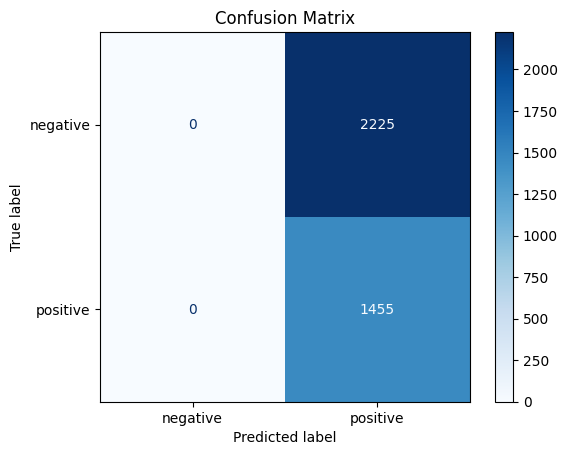


Precision-Recall AUC: 0.3572


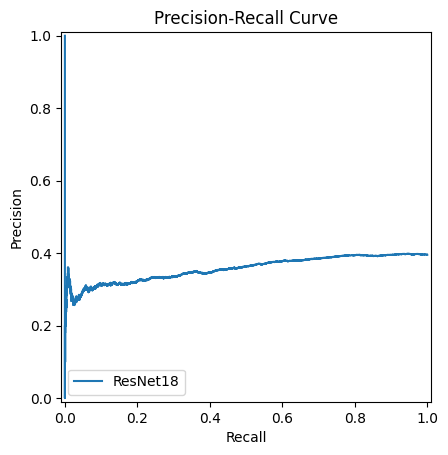


ROC AUC: 0.4549


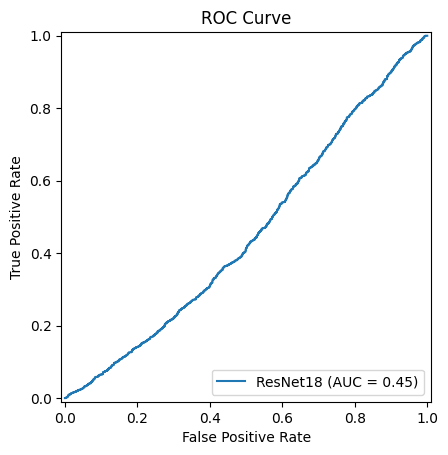

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, roc_curve, RocCurveDisplay, PrecisionRecallDisplay, auc
import torch
from torch.utils.data import DataLoader

# Ensure MURADataset, train_tfms, val_tfms, and path are defined (as they are in previous cells)

# Define the evaluation function
def evaluate_and_get_metrics(model, data_loader, device):
    model.eval()  # Set the model to evaluation mode
    all_labels = []
    all_preds = []
    all_probs = []  # To store probabilities for ROC and PR curves

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            probabilities = torch.softmax(logits, dim=1)
            preds = torch.argmax(probabilities, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probabilities[:, 1].cpu().numpy()) # Probabilities for the positive class

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

# Get device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Re-initialize the validation DataLoader, as it was previously local to train_model
val_csv = os.path.join(path, 'MURA_fn_dev.csv')
val_loader = DataLoader(
    MURADataset(val_csv, root_dir_path=path, transform=val_tfms),
    batch_size=16, shuffle=False, num_workers=2)

# Load the trained model if it's not already loaded (assuming model variable is available from previous cells)
# For this context, assuming 'model' is already loaded by cell ALFzSx4ZkAD6
if 'model' not in locals() or model is None:
    print("Loading model...")
    model = MURAClassifier()
    model.load_state_dict(torch.load('mura_resnet50_fulldataset25epo.pt'))
    model.eval()

# Ensure the model is on the correct device
model = model.to(device)

# Evaluate the model to get predictions and probabilities
true_labels, predicted_labels, predicted_probabilities = evaluate_and_get_metrics(model, val_loader, device)

# 1. Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)
print("\nConfusion Matrix:")
print(cm)

display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['negative', 'positive'])
display.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# 2. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(true_labels, predicted_probabilities)
pr_auc = auc(recall, precision)
print(f"\nPrecision-Recall AUC: {pr_auc:.4f}")

display_pr = PrecisionRecallDisplay(precision=precision, recall=recall, estimator_name="ResNet18")
display_pr.plot()
plt.title('Precision-Recall Curve')
plt.show()

# 3. ROC Curve
fpr, tpr, _ = roc_curve(true_labels, predicted_probabilities)
roc_auc = auc(fpr, tpr)
print(f"\nROC AUC: {roc_auc:.4f}")

display_roc = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="ResNet18")
display_roc.plot()
plt.title('ROC Curve')
plt.show()

In [29]:
import numpy as np

# Assuming 'cm' variable from previous execution is available
if 'cm' in locals():
    print("Generated Confusion Matrix:")
    print(cm)
else:
    print("Error: Confusion Matrix (cm) not found. Please ensure the evaluation cell has been run.")


Generated Confusion Matrix:
[[   0 2225]
 [   0 1455]]


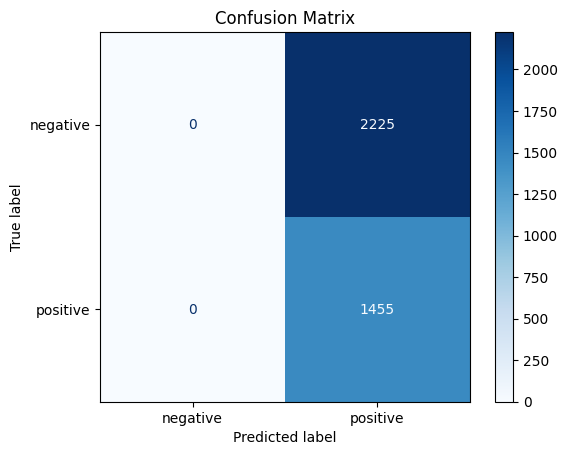

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Assuming 'cm' variable is available from previous execution
if 'cm' in locals():
    display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['negative', 'positive'])
    display.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.show()
else:
    print("Error: Confusion Matrix (cm) not found. Please ensure the evaluation cell has been run.")

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Assuming 'true_labels' and 'predicted_labels' are available from previous evaluation
# and 'cm' (confusion matrix) is also available.

if 'cm' in locals() and 'true_labels' in locals() and 'predicted_labels' in locals():
    print("\n--- Additional Validation Metrics ---")

    # Unpack confusion matrix values
    tn, fp, fn, tp = cm.ravel()

    # 1. Accuracy
    accuracy = accuracy_score(true_labels, predicted_labels)
    print(f"Accuracy: {accuracy:.4f}")

    # 2. Precision (for the positive class, label 1)
    # 'pos_label=1' specifies that 'positive' is our positive class
    precision = precision_score(true_labels, predicted_labels, pos_label=1)
    print(f"Precision: {precision:.4f}")

    # 3. Recall (Sensitivity) (for the positive class, label 1)
    recall = recall_score(true_labels, predicted_labels, pos_label=1)
    print(f"Recall (Sensitivity): {recall:.4f}")

    # 4. F1-Score (for the positive class, label 1)
    f1 = f1_score(true_labels, predicted_labels, pos_label=1)
    print(f"F1-Score: {f1:.4f}")

    # 5. Specificity (True Negative Rate)
    # Specificity = True Negatives / (True Negatives + False Positives)
    specificity = tn / (tn + fp)
    print(f"Specificity: {specificity:.4f}")

else:
    print("Error: Required variables (cm, true_labels, predicted_labels) not found. Please ensure the evaluation cell has been run.")


--- Additional Validation Metrics ---
Accuracy: 0.3954
Precision: 0.3954
Recall (Sensitivity): 1.0000
F1-Score: 0.5667
Specificity: 0.0000


In [32]:
from sklearn.metrics import cohen_kappa_score

# Assuming 'true_labels' and 'predicted_labels' are available from previous evaluation
if 'true_labels' in locals() and 'predicted_labels' in locals():
    kappa = cohen_kappa_score(true_labels, predicted_labels)
    print(f"\nCohen's Kappa: {kappa:.4f}")
else:
    print("Error: Required variables (true_labels, predicted_labels) not found. Please ensure the evaluation cell has been run.")


Cohen's Kappa: 0.0000


In [33]:
!exit()

/bin/bash: -c: line 2: syntax error: unexpected end of file
